In [1]:
using DifferentialEquations
using Plots

  3.102676 seconds (5.42 M allocations: 284.403 MiB, 8.70% gc time, 99.88% compilation time)
0.03940725734085411


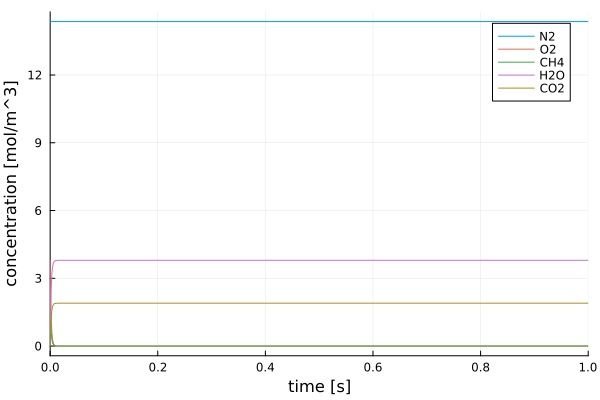

In [2]:
#temperature (assumed constant)
T = 900 #K

#initial species concentrations 1. N2, 2. O2, 3. CH4, 4. H2O, 5. CO2
X0 = 20.06*[7.57/10.57, 2/10.57, 1/10.57, 0, 0] #mol/m^3

# 2*O2 + CH4 -> 2*H2O + CO2
S = [0, -2, -1, 2, 1]

function Arrhenius(T, X)
    # Constants from Westbrook & Dryer 1981
    n_CH4 = -0.3
    n_O2 = 1.3
    A = 1.3e8 * 1e6
    Ea = 48.4 * 4184 # kcal/mol to J/mol
    R = 8.314 # J/mol/K
    
    # Ensure positive concentrations for exponentiation
    CH4_concentration = max(X[3], 0)
    O2_concentration = max(X[2], 0)
    
    k = A * exp(-Ea / (R * T)) # rate constant
    r = k * CH4_concentration^n_CH4 * O2_concentration^n_O2 # reaction rate
    return r
end

function f!(dX, X, p, t)
    r = Arrhenius(T, X)
    dX .= r .* S
end

# define
tend = 1
tspan = (0, tend)

# define problem 
problem = ODEProblem(f!, X0, tspan)

# solve problem 
@time sol = solve(problem, alg_hints=[:stiff], abstol = 1e-6, reltol = 1e-4)

function relaxation_time(sol)
    final = sol.u[end]
    for (i, u) in enumerate(sol.u)
        if all(abs.(u .- final) .< tol)
            return sol.t[i]
        end
    end
    return NaN  # If never within tolerance
end

τ = relaxation_time(sol)
println("Relaxation time: $τ seconds")


println(relaxation_time_by_derivative(sol,1e-6))

# plot solution obtained 
plot1 = plot(sol, xaxis="time [s]", yaxis="concentration [mol/m^3]", label=["N2" "O2" "CH4" "H2O" "CO2"])

plot(plot1, legend=true)
# savefig("1stepnoT")